In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from matplotlib import style
import seaborn as sns
from matplotlib import pyplot as plt

color=['0.3', '0.5', '0.7', '0.9']
linestyle=['-', '--', ':', '-.']
marker=['o', 'v', 'd', 'p']

pd.set_option('display.max_rows', 6)
from IPython.display import HTML
import networkx as nx

In [2]:
# =============================================================================
#  APPLY THEME  --  Beamer "Madrid" look. Re-run any time to refresh styling.
# =============================================================================
from pywrangling.jupyter_slides_functions import apply_beamer_theme
from pywrangling.graphing_functions import use_plotplainblind, set_top_ylabel
apply_beamer_theme(
    "madrid",
    skip_font_download=True,
    author="Robert Pettis",
    date="Fall 2026",
    show_slide_number=True,
    cell_tags=True,
    notebook_path="04b-Checkpoint-Quiz.ipynb",
)
import course_helpers as chh

<IPython.core.display.Javascript object>


✓ Cell tag CSS applied for 5 cell(s):
 cell_index slide_id                                  tags
          0          slide_hide_prompt, slide_remove_input
          1          slide_hide_prompt, slide_remove_input
          2          slide_hide_prompt, slide_remove_input
          6          slide_hide_prompt, slide_remove_input
         15          slide_hide_prompt, slide_remove_input


In [3]:
# Presenter clicker remap. Guarded so a student's Restart & Run All
# never breaks on it if pywrangling is missing.
try:
    from pywrangling.jupyter_slides_functions import enable_reveal_key_remap
    enable_reveal_key_remap({
        38: "left",         # Up arrow   -> previous  (clicker left button)
        40: "right",        # Down arrow -> next      (clicker right button)
        27: "up",           # Escape     -> up        (clicker play button)
        66: "down",         # B          -> down      (clicker stop button)
        116: None,          # F5         -> block refresh
        9:  "togglePause",  # Tab        -> black screen
    })
except Exception:
    pass  # not presenting, or pywrangling not installed

<div class="beamer-meta" data-author="Robert Pettis" data-date="Fall 2026"></div>

# Checkpoint


<br>

<b style="color:#73000A;">Robert Pettis</b>
Fall 2026

## How This Works

- Six questions, about ten minutes
- Read it, pick an answer, and be ready to say <b style="color:#73000A;">why</b>. I will call on people
- Being wrong here is the cheapest it will ever be. Wrong answers tell me what to teach again
- No notes, no laptops. Every question is about ideas, not arithmetic

### Question 1: The Bank's Own Numbers

A bank regresses default on credit limit and nothing else. The slope comes out negative: customers with bigger credit lines default less.

What is that slope measuring?

- <b style="color:#73000A;">A.</b> The pure effect of credit on default
- <b style="color:#73000A;">B.</b> The bank's own lending policy, since it handed the biggest lines to the safest customers
- <b style="color:#73000A;">C.</b> Nothing, because default is 0 or 1 and the slope is tiny
- <b style="color:#73000A;">D.</b> The effect of credit, measured on too few customers to be sure

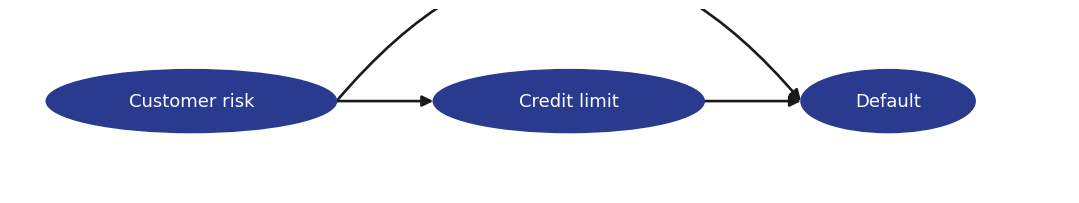

In [4]:
chh.draw_dag([("Customer risk", "Credit limit"), ("Customer risk", "Default"),
              ("Credit limit", "Default")])

### Question 2: Comparing Lookalikes

A potential correction is to gather customers who match on everything the bank knew, compare high limits with low inside each group, then average those comparisons.

The bank lends on about ten variables. Why can it not just do that?

- <b style="color:#73000A;">A.</b> Averaging comparisons only works when the treatment is yes or no
- <b style="color:#73000A;">B.</b> The comparison needs a model of default, and there is not one
- <b style="color:#73000A;">C.</b> Almost every group ends up holding one customer, and one customer has nobody to compare against
- <b style="color:#73000A;">D.</b> It would work, but the arithmetic takes too long to run

### Question 3: Two Problems, Two Fixes

Spending rises with the credit limit, but the curve bends. You take the <b style="color:#73000A;">square root</b> of the limit and the relationship straightens out.

Wage drives both the limit and spending, and wage is not in the model.

What has the square root fixed?

- <b style="color:#73000A;">A.</b> Everything. A straight relationship is an unconfounded one
- <b style="color:#73000A;">B.</b> The shape only. The confounding is still there... wage still has to go into the model
- <b style="color:#73000A;">C.</b> The confounding only, since transforming the limit breaks its link to wage
- <b style="color:#73000A;">D.</b> Neither. A transformation cannot move an estimate

### Question 4: The Right Angle

Fit any regression and the leftovers meet the fitted surface at a right angle.

That right angle means:

- <b style="color:#73000A;">A.</b> The residuals are normally distributed
- <b style="color:#73000A;">B.</b> The residuals are uncorrelated with every variable in the model
- <b style="color:#73000A;">C.</b> The residuals have the same spread at every value of $X$
- <b style="color:#73000A;">D.</b> The residuals are uncorrelated with each other

### Question 5: Debias and Denoise

To get the effect of credit limit holding wage fixed, you can run two small regressions and then a third:

1. Take wage out of the <b style="color:#73000A;">limit</b>, keep the leftover (residuals)
2. Take wage out of <b style="color:#73000A;">default</b>, keep the leftover
3. Regress leftover on leftover

Skip step 2. Regress raw default on the leftover limit. What changes?

- <b style="color:#73000A;">A.</b> Nothing at all
- <b style="color:#73000A;">B.</b> The estimate is confounded by wage again
- <b style="color:#73000A;">C.</b> The estimate is the same, but the standard error is bigger
- <b style="color:#73000A;">D.</b> The estimate changes, but the standard error does not

### Question 6: A Control That Costs You

One variable in your data predicts the treatment almost perfectly. It has nothing to do with the outcome except through the treatment.

You add it as a control. What happens?

- <b style="color:#73000A;">A.</b> Bias falls, so it earns its place
- <b style="color:#73000A;">B.</b> Nothing, since it never touches the outcome
- <b style="color:#73000A;">C.</b> It soaks up the treatment's variation, and the estimate gets much less precise
- <b style="color:#73000A;">D.</b> It opens a back door and biases the estimate

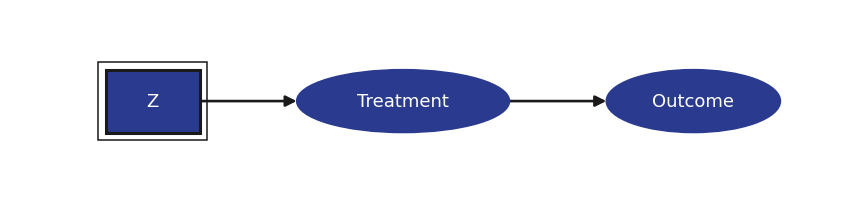

In [5]:
chh.draw_dag([("Z", "Treatment"), ("Treatment", "Outcome")], boxed=("Z",))